<a href="https://colab.research.google.com/github/KangDongJun-ux/MOBILITY/blob/main/%EB%94%A5%EB%9F%AC%EB%8B%9D_%EA%B0%95%EC%9D%98_%ED%8C%8C%EB%9D%BC%EB%A9%94%ED%84%B0%EC%9D%98_%ED%95%99%EC%8A%B5%EA%B3%BC%EC%A0%95_%EC%9D%8C%EB%AF%B8%2C_MSE%2C_%ED%8C%8C%EC%9D%B4%ED%86%A0%EC%B9%98%EC%8B%9D_%EC%BD%94%EB%94%A9%ED%8C%A8%ED%84%B4_%EC%97%B0%EC%8A%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [61]:
import torch
import numpy as np
import matplotlib.pyplot as plt

In [62]:
plt.rcParams['figure.figsize'] = (4.5, 3.0)

# **4. 파라미터의 학습과정 음미**

In [63]:
torch.manual_seed(10)
x,_ = torch.randn(100).sort()
eps = torch.randn(100)*0.5
X = torch.stack([torch.ones(100),x], axis = 1)
W = torch.tensor([[2.5],[4.0]])
y = X@W + eps.reshape(100,1)
x = X[:,[1]]

In [64]:
# 지도학습문제: (x,y) 관찰하고 x -> y 인 패턴을 찾는 문제 (지도학습문제, supervised learning)
# 모델링: (x,y) 관찰을 해보니까 scatter plot이 직선의 모양을 하고 있음.. --> 패턴이 직선이겠네? --> y=X@W+ϵ
## - 모델: y=X@W+ϵ // y 물결 X@W
# 학습: 결국 회귀분석문제는 What을 찾는 문제 // 파라메터 What의 값을 update하는 과정을 학습
# 학습의 방법
# 1. yhat을 구한다.
# 2. loss를 계산한다.
# 3. loss미분한다.
# 4. update한다.

## A. print

In [65]:
What = torch.tensor([[-5.0],[10.0]], requires_grad=True)
alpha = 0.001
print(f"시작값 = {What.data.reshape(-1)}")
for epoc in range(30):
  yhat = X@What
  loss = torch.sum((y-yhat)**2)
  loss.backward()
  What.data = What.data - alpha*What.grad
  print(f"loss = {loss:.2f} \t 업데이트폭 = {-alpha*What.grad.reshape(-1)} \t 업데이트결과: {What.data.reshape(-1)}")
  What.grad = None

시작값 = tensor([-5., 10.])
loss = 10221.10 	 업데이트폭 = tensor([ 1.5897, -1.4189]) 	 업데이트결과: tensor([-3.4103,  8.5811])
loss = 6187.17 	 업데이트폭 = tensor([ 1.2497, -1.0858]) 	 업데이트결과: tensor([-2.1605,  7.4953])
loss = 3751.81 	 업데이트폭 = tensor([ 0.9829, -0.8304]) 	 업데이트결과: tensor([-1.1776,  6.6650])
loss = 2280.42 	 업데이트폭 = tensor([ 0.7734, -0.6346]) 	 업데이트결과: tensor([-0.4042,  6.0304])
loss = 1390.73 	 업데이트폭 = tensor([ 0.6089, -0.4846]) 	 업데이트결과: tensor([0.2047, 5.5457])
loss = 852.30 	 업데이트폭 = tensor([ 0.4796, -0.3698]) 	 업데이트결과: tensor([0.6843, 5.1759])
loss = 526.14 	 업데이트폭 = tensor([ 0.3779, -0.2820]) 	 업데이트결과: tensor([1.0622, 4.8939])
loss = 328.38 	 업데이트폭 = tensor([ 0.2979, -0.2148]) 	 업데이트결과: tensor([1.3601, 4.6791])
loss = 208.35 	 업데이트폭 = tensor([ 0.2350, -0.1635]) 	 업데이트결과: tensor([1.5952, 4.5156])
loss = 135.40 	 업데이트폭 = tensor([ 0.1855, -0.1243]) 	 업데이트결과: tensor([1.7806, 4.3913])
loss = 91.03 	 업데이트폭 = tensor([ 0.1464, -0.0944]) 	 업데이트결과: tensor([1.9271, 4.2968])
loss = 63.99 	 업

## B. 시각화 -yhat의 관점에서!

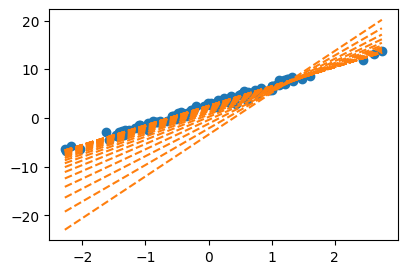

In [66]:
from pathlib import WindowsPath
What = torch.tensor([[-5.0],[10.0]], requires_grad=True)
alpha = 0.001
plt.plot(x,y,'o', label=r"obeserved")
fig = plt.gcf() # 사진 전체를 지정
ax = fig.gca() # 사진의 축 x,y를 모두 포함한 것이 ax임, subplot일 경우 x,y축인 ax가 여러 개가 되는 것임.
for epoc in range(30):
  yhat = X@What
  loss = torch.sum((y-yhat)**2)
  loss.backward()
  What.data = What.data - alpha*What.grad
  ax.plot(x,X@What.data, '--', color = 'C1')
  What.grad = None

## C. 시각화 -- loss의 관점에서!

In [67]:
def plot_loss():
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')
    w0 = np.arange(-6, 11, 0.5)
    w1 = np.arange(-6, 11, 0.5)
    W1,W0 = np.meshgrid(w1,w0)
    LOSS=W0*0
    for i in range(len(w0)):
        for j in range(len(w1)):
            LOSS[i,j]=torch.sum((y-w0[i]-w1[j]*x)**2)
    ax.plot_surface(W0, W1, LOSS, rstride=1, cstride=1, color='b',alpha=0.1)
    ax.azim = 30  ## 3d plot의 view 조절
    ax.dist = 8   ## 3d plot의 view 조절
    ax.elev = 5   ## 3d plot의 view 조절
    ax.set_xlabel(r'$w_0$')  # x축 레이블 설정
    ax.set_ylabel(r'$w_1$')  # y축 레이블 설정
    ax.set_xticks([-5,0,5,10])  # x축 틱 간격 설정
    ax.set_yticks([-5,0,5,10])  # y축 틱 간격 설정
    plt.close(fig)  # 자동 출력 방지
    return fig

In [68]:
def l(w0hat, w1hat):  # loss 구하는 함수
  yhat = w0hat + w1hat*X
  return torch.sum((y-yhat)**2)

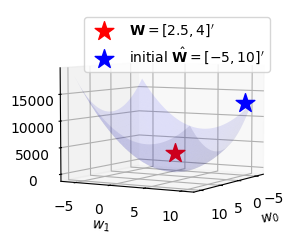

In [69]:
fig = plot_loss()
ax = fig.gca()
ax.scatter(2.5, 4, l(2.5,4), s=200, marker='*', color='red', label=r"${\bf W}=[2.5, 4]'$")
ax.scatter(-5, 10, l(-5,10), s=200, marker='*', color='blue', label=r"initial $\hat{\bf W}=[-5, 10]'$")
ax.legend()
fig

In [70]:
What = torch.tensor([[-5.0],[10.0]], requires_grad=True)
alpha = 0.001
for epoc in range(30):
  yhat = X@What
  loss = torch.sum((y-yhat)**2)
  loss.backward()
  What.data = What.data - alpha*What.grad
  w0, w1 = What.data.reshape(-1)
  ax.scatter(w0,w1,l(w0,w1), s=5, marker='o', color='blue')
  What.grad = None

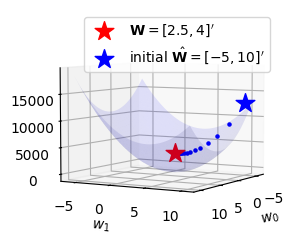

In [71]:
fig

## D. 애니메이션

In [72]:
from matplotlib import animation

In [73]:
plt.rcParams['figure.figsize'] = (7.5, 2.5)
plt.rcParams["animation.html"] = 'jshtml'

In [74]:
def show_animation(alpha=0.001):
    ## 1. 히스토리 기록을 위한 list 초기화
    loss_history = []
    yhat_history = []
    What_history = []

    ## 2. 학습 + 학습과정기록
    What= torch.tensor([[-5.0],[10.0]],requires_grad=True)
    What_history.append(What.data.tolist())
    for epoc in range(30):
        yhat=X@What ; yhat_history.append(yhat.data.tolist())
        loss=torch.sum((y-yhat)**2); loss_history.append(loss.item())
        loss.backward()
        What.data = What.data - alpha * What.grad; What_history.append(What.data.tolist())
        What.grad = None

    ## 3. 시각화
    fig = plt.figure()
    ax1 = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')

    #### ax1: yhat의 관점에서..
    ax1.plot(x,y,'o',label=r"$(x_i,y_i)$")
    line, = ax1.plot(x,yhat_history[0],label=r"$(x_i,\hat{y}_i)$")
    ax1.legend()
    #### ax2: loss의 관점에서..
    w0 = np.arange(-6, 11, 0.5)
    w1 = np.arange(-6, 11, 0.5)
    W1,W0 = np.meshgrid(w1,w0)
    LOSS=W0*0
    for i in range(len(w0)):
        for j in range(len(w1)):
            LOSS[i,j]=torch.sum((y-w0[i]-w1[j]*x)**2)
    ax2.plot_surface(W0, W1, LOSS, rstride=1, cstride=1, color='b',alpha=0.1)
    ax2.azim = 30  ## 3d plot의 view 조절
    ax2.dist = 8   ## 3d plot의 view 조절
    ax2.elev = 5   ## 3d plot의 view 조절
    ax2.set_xlabel(r'$w_0$')  # x축 레이블 설정
    ax2.set_ylabel(r'$w_1$')  # y축 레이블 설정
    ax2.set_xticks([-5,0,5,10])  # x축 틱 간격 설정
    ax2.set_yticks([-5,0,5,10])  # y축 틱 간격 설정
    ax2.scatter(2.5, 4, l(2.5,4), s=200, marker='*', color='red', label=r"${\bf W}=[2.5, 4]'$")
    ax2.scatter(-5, 10, l(-5,10), s=200, marker='*', color='blue')
    ax2.legend()
    def animate(epoc):
        line.set_ydata(yhat_history[epoc])
        ax2.scatter(np.array(What_history)[epoc,0],np.array(What_history)[epoc,1],loss_history[epoc],color='grey')
        fig.suptitle(f"alpha = {alpha} / epoch = {epoc}")
        return line

    ani = animation.FuncAnimation(fig, animate, frames=30)
    plt.close()
    return ani

In [75]:
ani = show_animation(alpha=0.001)
ani

## E. 학습률에 따른 시각화

`-` $\alpha$가 너무 작다면 비효율적임

In [76]:
show_animation(alpha=0.0001)

`-` $\alpha$가 크다고 무조건 좋은건 또 아님

In [77]:
show_animation(alpha=0.0083)

`-` 수틀리면 수렴 안할 수도??

In [78]:
show_animation(alpha=0.0085)

`-` 그냥 망할 수도

In [79]:
show_animation(alpha=0.01)

In [80]:
plt.rcdefaults()
plt.rcParams['figure.figsize'] = 4.5,3.0

# 5. **SSE $\to$ MSE**

`-` 학습률을 잘 선택하는 것이 중요함.

`-` 손실함수를 SSE로 설정하면 학습률 선택이 비효율적 $\to$ SSE 말고 MSE를 써야함.

**손실함수가 SSE일 때 코드**

In [81]:
What = torch.tensor([[-5.0],[10.0]],requires_grad=True)
alpha = 0.001
for epoc in range(30):
  # step 1: yhat
  yhat = X@What
  # step 2: loss
  loss = torch.sum((y-yhat)**2)
  # step 3: 미분
  loss.backward()
  # step 4: update
  What.data = What.data - alpha*What.grad
  What.grad = None

In [82]:
What.data

tensor([[2.4759],
        [4.0076]])

**손실함수가 MSE일 때 코드**

In [83]:
What = torch.tensor([[-5.0],[10.0]],requires_grad=True)
for epoc in range(30):
  # step 1: yhat
  yhat = X@What
  # step 2: loss
  loss = torch.sum((y-yhat)**2)/100 # torch.mean((y-yhat)**2)
  # step 3: 미분
  loss.backward()
  # step 4: update
  What.data = What.data - 0.1*What.grad
  What.grad = None

# alpha를 크게 설정한 이유
# 지금까지 SSE는 loss를 제곱하여 더했기 때문에 큰 값이 나왔고 이를 미분해도 큰 값이 나옴.
# 하지만 MSE는 loss를 제곱하여 data개수로 나눠주기 때문에 더 작은 값이 나오고 이를 미분해도 작은 값이 출력됨.
# 따라서 MSE를 사용할 때 SSE처럼 학습률을 작게 설정하면 학습 진행이 느려지므로 크게 설정

In [84]:
What.data

tensor([[2.4759],
        [4.0076]])

# **6. 파이토치식 코딩패턴(1)**

In [85]:
torch.manual_seed(10)
x,_ = torch.randn(100).sort()
eps = torch.randn(100)*0.5
X = torch.stack([torch.ones(100), x], axis = 1)
W = torch.tensor([[2.5],[4.0]])
y = X@W + eps.reshape(100,1)
x = X[:,[1]]

## A. 기본패턴

In [86]:
##-- 외워라!! -- ##
What = torch.tensor([[-5.0],[10.0]], requires_grad= True)
for epoc in range(30):
  # step 1: yhat
  yhat = X@What
  # step 2: loss
  loss = torch.mean((y-yhat)**2)
  # step 3: 미분
  loss.backward()
  # step 4: update
  What.data = What.data - 0.1*What.grad
  What.grad = None

Text(0.5, 1.0, 'tensor([2.4759, 4.0076])')

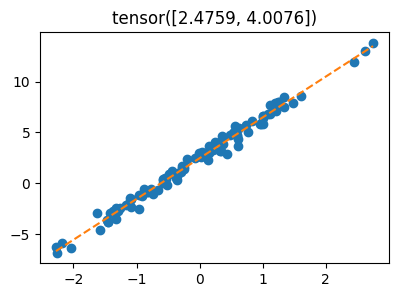

In [87]:
plt.plot(x,y,'o')
plt.plot(x,X@What.data, '--')
plt.title(f"{What.data.reshape(-1)}")

## B. Step2의 수정 -- `loss_fn` 이용

In [88]:
What = torch.tensor([[-5.0],[10.0]], requires_grad=True)
loss_fn = torch.nn.MSELoss()
for epoc in range(30):
  # step 1: yhat
  yhat = X@What
  # step 2: loss
  loss = loss_fn(yhat, y) # 습관적으로 yhat을 먼저 넣는 연습을 하자
  # step 3: 마분
  loss.backward()
  # step 4: update
  What.data = What.data - 0.1*What.grad
  What.grad = None

Text(0.5, 1.0, 'What =tensor([2.4759, 4.0076])')

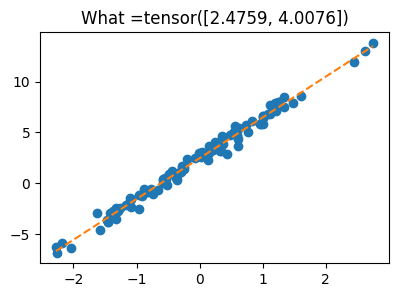

In [89]:
plt.plot(x,y,'o')
plt.plot(x, X@What.data, '--')
plt.title(f"What ={What.data.reshape(-1)}")

## C. Step 1 수정 -- `net` 이용

In [90]:
What = torch.tensor([[-5.0],[10.0]], requires_grad=True)
yhat = X@What
yhat[:5]

tensor([[-27.7742],
        [-27.6444],
        [-26.8060],
        [-25.4104],
        [-21.1924]], grad_fn=<SliceBackward0>)

아래와 같은 방식으로 코드를 짜고 싶음..
```Python
yhat = net(X) #
```

위와 같은 코드를 가능하게 하는 `net`은 torch에서 지원하고 아래와 같이 사용할 수 있음.

In [91]:
net  = torch.nn.Linear(
    in_features= 2, # X : (n,2) --> 입력 특성이 2개
    out_features= 1, # yhat: (n,1) --> 출력 특성은 1개
    bias = False
)

In [92]:
net.weight.data = torch.tensor([[-5.0],[10.0]]).T # .T를 해야 함. 외워라 # 미분을 옵션으로 넣지 않아도 미분기 가능한 것으로 보임.(출력 값을 보면 )
net.weight

Parameter containing:
tensor([[-5., 10.]], requires_grad=True)

In [93]:
net(X)[:5]

tensor([[-27.7742],
        [-27.6444],
        [-26.8060],
        [-25.4104],
        [-21.1924]], grad_fn=<SliceBackward0>)

In [94]:
(X@What)[:5]

tensor([[-27.7742],
        [-27.6444],
        [-26.8060],
        [-25.4104],
        [-21.1924]], grad_fn=<SliceBackward0>)

In [95]:
(X@net.weight.T)[:5]

tensor([[-27.7742],
        [-27.6444],
        [-26.8060],
        [-25.4104],
        [-21.1924]], grad_fn=<SliceBackward0>)

`-` 수정된 코드

In [96]:
# step 1을 위한 사전준비
net = torch.nn.Linear(
    in_features=2,
    out_features=1,
    bias = False
)

net.weight.data = torch.tensor([[-5.0, 10.0]]) # torch.tensor([[-5.0],[10.0]]).T 와 같으므로 이렇게 작성
# step 2를 위한 사전준비
loss_fn = torch.nn.MSELoss()
for epoc in range(30):
  # step 1: yhat
  # yhat = X@What
  yhat  = net(X)
  # step 2: loss
  loss = loss_fn(yhat, y)
  # step 3: 미분
  loss.backward()
  # step 4: update
  net.weight.data = net.weight.data - 0.1*net.weight.grad
  net.weight.grad = None

Text(0.5, 1.0, 'What = tensor([2.4759, 4.0076])')

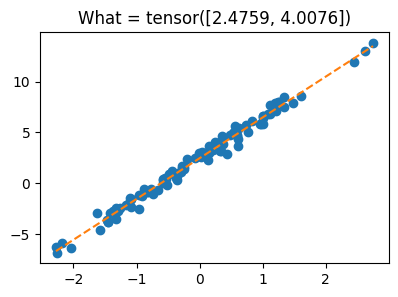

In [97]:
plt.plot(x,y,'o')
plt.plot(x,net(X).data,'--')
plt.title(f"What = {net.weight.data.reshape(-1)}")

## D. step 4의 수정 -- `optimizer`의 이용

`-` 소망: 아래의 과정을 좀 더 편하게 했으면 좋겠다.
```Python
net.weight.data = net.weight.data - 0.1*net.weight.grad
net.weight.grad = None
```

`# optimizer` -- 이걸 이용하면 update 과정을 손쉽게 할 수 있음.

**기존코드**

In [101]:
##-- 준비과정 -- ##
# step 1을 위한 사전준비
net = torch.nn.Linear(
    in_features = 2,
    out_features=1,
    bias = False
)
net.weight.data = torch.tensor([[-5.0,10.0]])
# step2를 위한 사전준비
loss_fn = torch.nn.MSELoss()


In [102]:
## --1 에폭진행 -- ##
yhat = net(X)
loss = loss_fn(yhat,y)
loss.backward()
print(net.weight.data)
net.weight.data = net.weight.data - 0.1*net.weight.grad
print(net.weight.data)
net.weight.grad = None

tensor([[-5., 10.]])
tensor([[-3.4103,  8.5811]])


In [105]:
## -- 2에폭진행 -- ##
# step1: 2에폭 진행
yhat = net(X)
# step2: loss
loss = loss_fn(yhat,y)
# step3: 미분
loss.backward()
# step4: update
print(net.weight.data)
net.weight.data = net.weight.data - 0.1*net.weight.grad
print(net.weight.data)
net.weight.grad = None

tensor([[-3.4103,  8.5811]])
tensor([[-2.1605,  7.4953]])


새로운코드 -- `optimizer` 이용

In [107]:
net = torch.nn.Linear(
    in_features=2,
    out_features=1,
    bias = False
)
net.weight.data = torch.tensor([[-5.0,10.0]])
loss_fn = torch.nn.MSELoss()
# step4를 위한 사전준비
optimzr = torch.optim.SGD(net.parameters(), lr=0.1)

In [108]:
yhat = net(X)
loss = loss_fn(yhat,y)
loss.backward()
# step4: update
# net.weight.data = net.weight.data - 0.1*net.weight.grad
optimzr.step()
print(net.weight.data)
# net.weight.grad = None
optimzr.zero_grad()

tensor([[-3.4103,  8.5811]])


In [109]:
## -- 2에폭진행 -- ##
# step 1: yhat
yhat = net(X)
# step 2: loss
loss = loss_fn(yhat,y)
# step 3: 미분
loss.backward()
# step 4: update
optimzr.step()
optimzr.zero_grad()

`-` 최종 코드(수정된 코드)

In [111]:
# step1을 위한 사전 준비
net = torch.nn.Linear(
    in_features=2,
    out_features=1,
    bias = False
)
# 초기 weight 설정
net.weight.data = torch.tensor([[-5.0, 10.0]])
# step 2를 위한 사전준비
loss_fn = torch.nn.MSELoss()
#step 4를 위한 사전 준비
optimzr = torch.optim.SGD(net.parameters(), lr=0.1)
for epoc in range(30):
  # step 1: yhat
  yhat  = net(X)
  # stpe 2: loss
  loss = loss_fn(yhat, y)
  # step 3: 미분
  loss.backward()
  # step 4: update
  optimzr.step()
  optimzr.zero_grad()

Text(0.5, 1.0, 'net.weight = tensor([2.4759, 4.0076])')

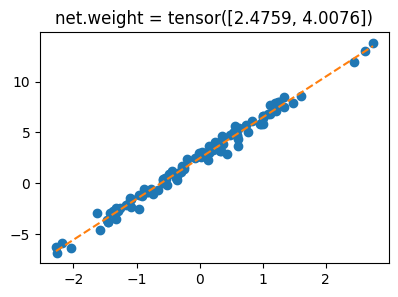

In [112]:
plt.plot(x,y,'o')
plt.plot(x, net(X).data, '--')
plt.title(f'net.weight = {net.weight.data.reshape(-1)}')